[Link to dataset: Smart Grid Real-Time Load Monitoring Dataset](https://www.kaggle.com/datasets/ziya07/smart-grid-real-time-load-monitoring-dataset)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import shutil
from pathlib import Path
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import shap
from utils.mi_face_SHAP import MIFace_SHAP
import json
from art.attacks.inference.model_inversion.mi_face import MIFace
from utils.keras2 import KerasClassifier
import keras
from tqdm import tqdm
import os


import tensorflow as tf
#tf.compat.v1.disable_eager_execution()
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.neighbors import NearestNeighbors

from sklearn.utils.class_weight import compute_class_weight

In [ ]:
dataset_rs = 42
max_iteration = 10000
# seed important for x_init generation
seed=42
np.random.seed(seed)

print(tf.__version__)
print(keras.__version__)

2.19.0
3.14.1


In [15]:
# For downloading dataset
dst_path = Path.cwd() / "input" / "smart-grid-real-time-load-monitoring-dataset"

if not (dst_path / "smart_grid_dataset.csv").exists():

    # Download latest version
    src_path = Path(kagglehub.dataset_download("ziya07/smart-grid-real-time-load-monitoring-dataset"))
    
    # Destination: current working directory
    
    
    dst_path.mkdir(parents=True, exist_ok=True)
    
    # Copy all files
    for item in src_path.iterdir():
        if item.is_file():
            shutil.copy(item, dst_path / item.name)
    
    print("Dataset copied to:", dst_path)

In [16]:
# Load data
print("Loading file...")
try:
    df_base =pd.read_csv('input/smart-grid-real-time-load-monitoring-dataset/smart_grid_dataset.csv',delimiter=',')
    print(f"✓ Loaded {len(df_base):,} total rows")
except FileNotFoundError as e:
    print(f"✗ Error: File '{e.filename}' not found!")
except Exception as e:
    print(f"✗ Error loading file: {e}")

Loading file...
✓ Loaded 50,000 total rows


In [ ]:
# Convert to proper pandas datetime objects
df_base['Timestamp'] = pd.to_datetime(df_base['Timestamp'])


# Create a copy for processing to keep the original df_base intact
df_processed = df_base.copy()
# sort the dataset by timestamp
df_processed = df_processed.sort_values(by="Timestamp", ascending=True).reset_index(drop=True)
print(df_processed.dtypes)
df_processed.head()

DataFrames are identical: True
Timestamp                      datetime64[us]
Voltage (V)                           float64
Current (A)                           float64
Power Consumption (kW)                float64
Reactive Power (kVAR)                 float64
Power Factor                          float64
Solar Power (kW)                      float64
Wind Power (kW)                       float64
Grid Supply (kW)                      float64
Voltage Fluctuation (%)               float64
Overload Condition                      int64
Transformer Fault                       int64
Temperature (°C)                      float64
Humidity (%)                          float64
Electricity Price (USD/kWh)           float64
Predicted Load (kW)                   float64
dtype: object


,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,0,0,38.760333,61.384213,0.290078,1.696639


In [18]:
# Data Cleaning

print("Cleaning Data...")

print("\nMissing values before cleaning:")
print(df_processed.isnull().sum())

df_processed.ffill(inplace=True)
df_processed.bfill(inplace=True)

print("\nMissing values after cleaning:")
print(df_processed.isnull().sum().sum())

print("\n✓ Finished Cleaning Data.")

Cleaning Data...

Missing values before cleaning:
Timestamp                      0
Voltage (V)                    0
Current (A)                    0
Power Consumption (kW)         0
Reactive Power (kVAR)          0
Power Factor                   0
Solar Power (kW)               0
Wind Power (kW)                0
Grid Supply (kW)               0
Voltage Fluctuation (%)        0
Overload Condition             0
Transformer Fault              0
Temperature (°C)               0
Humidity (%)                   0
Electricity Price (USD/kWh)    0
Predicted Load (kW)            0
dtype: int64

Missing values after cleaning:
0

✓ Finished Cleaning Data.


Creating combined Anomaly Label...
✓ 'Combined_Anomaly' column created.

Distribution of Combined_Anomaly:
Combined_Anomaly
0    43721
1     6279
Name: count, dtype: int64
✓ Combined Anomaly Label creation complete.


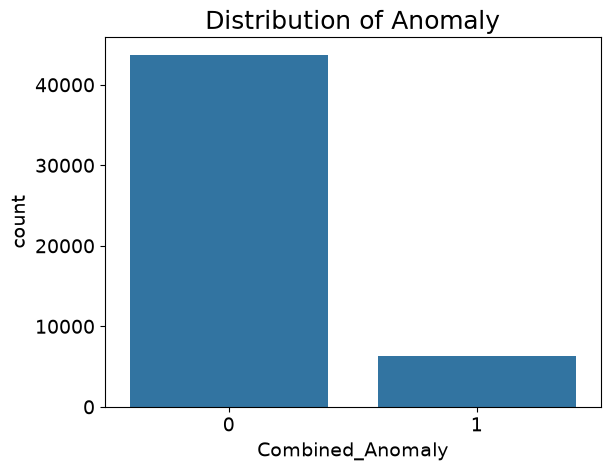

In [19]:
# Creating combined Anomaly Label
print("Creating combined Anomaly Label...")

if 'Overload Condition' in df_processed.columns and 'Transformer Fault' in df_processed.columns:
    df_processed['Combined_Anomaly'] = ((df_processed['Overload Condition'] == 1) | (df_processed['Transformer Fault'] == 1)).astype(int)
    print("✓ 'Combined_Anomaly' column created.")
else:
    print("✗ Warning: 'Overload Condition' or 'Transformer Fault' column not found. Skipping 'Combined_Anomaly' creation.")
    df_processed['Combined_Anomaly'] = 0
    print("A dummy 'Combined_Anomaly' column (all zeros) has been created. Anomaly detection will not be meaningful without true labels.")

print("\nDistribution of Combined_Anomaly:")
initial_anomaly_counts = df_processed['Combined_Anomaly'].value_counts()
print(initial_anomaly_counts)

print("✓ Combined Anomaly Label creation complete.")

plt.rcParams.update({
            'font.size': 16,
            'axes.titlesize': 18,
            'axes.labelsize': 14,
            'xtick.labelsize': 14,
            'ytick.labelsize': 14,
        })

# Visualize the distribution of the target variable
sns.countplot(x='Combined_Anomaly', data=df_processed)
plt.title('Distribution of Anomaly')
plt.show()


✓ Added timestamp data as features only for correlation analysis.


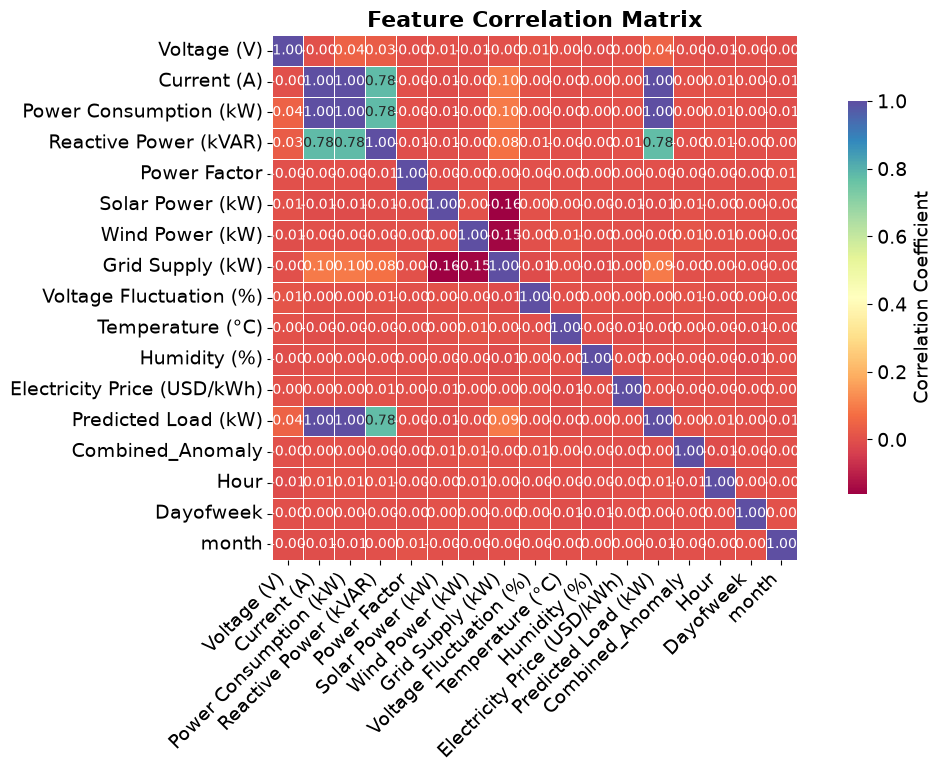

In [20]:

df_cor = df_processed.drop(['Transformer Fault', 'Overload Condition'], axis=1)
df_cor['Hour'] = df_processed['Timestamp'].dt.hour
df_cor['Dayofweek'] = df_processed['Timestamp'].dt.dayofweek
df_cor['month'] = df_processed['Timestamp'].dt.month
print("✓ Added timestamp data as features only for correlation analysis.")

# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation = df_cor.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Spectral",  # 🔥 Vibrant colormap: 'Spectral', 'coolwarm', 'viridis', etc.
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"},
    annot_kws={"fontsize": 10}
)
plt.title("Feature Correlation Matrix", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Shows low correlation when data is static for combined anomaly
# -> feature engineering of time information necessary

In [ ]:
print("Scaling Data...")

y_true_full = df_processed['Combined_Anomaly']

columns_to_exclude = [
    'Overload Condition', 'Transformer Fault', 'Combined_Anomaly',
    'Timestamp', 'Predicted Load (kW)'
]
X_cols = [col for col in df_processed.columns if col not in columns_to_exclude]
X = df_processed[X_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Features (X_scaled_df) shape after scaling: {X_scaled_df.shape}")
print(f"Labels (y_true_full) shape: {y_true_full.shape}")
print("✓ Data scaling complete.")


timestamp_s = pd.to_datetime(df_processed['Timestamp']).map(pd.Timestamp.timestamp)
hour = 60*60
day = 24*60*60
year = (365.2425)*day
X_scaled_df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
X_scaled_df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
X_scaled_df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
X_scaled_df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
print("✓ Added sine/cosine timestamp data as features")


print("\nFirst 5 rows of scaled features:")
print(X_scaled_df.head())
print("\nFirst 5 rows of target:")
print(y_true_full.head())

print(f"Features (X_scaled_df) shape after adding time: {X_scaled_df.shape}")


print("Feature Engineering...")

sequence_length = 4
print(f" Sequence Length is {sequence_length}")

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])  # Past 4 timesteps
        ys.append(y[i])            # Target: next timestep label
    return np.array(Xs), np.array(ys)


X_seq, y_seq = create_sequences(X_scaled_df.to_numpy(), y_true_full.to_numpy(), sequence_length)
print(f"One Data contains of {sequence_length} timestamps") 

min_array = np.min(X_seq, axis=(0,1))
max_array = np.max(X_seq, axis=(0,1))

clip_min = min_array
clip_max = max_array

X_train, X_t, y_train, y_t = train_test_split(X_seq, y_seq, test_size=0.40, random_state=dataset_rs, shuffle=False)
X_test, X_val, y_test, y_val = train_test_split(X_t, y_t, test_size=0.50, random_state=dataset_rs, shuffle=False)
print("Split complete.")

Scaling Data...
Features (X_scaled_df) shape after scaling: (50000, 12)
Labels (y_true_full) shape: (50000,)
✓ Data scaling complete.
✓ Added sine/cosine timestamp data as features

First 5 rows of scaled features:
   Voltage (V)  Current (A)  Power Consumption (kW)  Reactive Power (kVAR)  \
0     0.497056    -1.721938               -1.715484              -1.228261   
1    -0.137821    -0.405810               -0.410379              -0.348346   
2     0.648006     1.436332                1.484581               1.250252   
3     1.523207     1.553148                1.672641               0.386404   
4    -0.233695    -1.545917               -1.546838              -0.994354   

   Power Factor  Solar Power (kW)  Wind Power (kW)  Grid Supply (kW)  \
0      0.134538          1.492223         1.314934         -0.102543   
1     -1.180889         -1.258664         0.409409         -0.102543   
2      1.714734         -0.664915        -0.242790         -0.102543   
3     -0.061223          0.7

In [22]:
# check the distribution of the target variable in each split
print("\nDistribution of target variable in training set:")
print(pd.Series(y_train).value_counts())

print("\nDistribution of target variable in validation set:")
print(pd.Series(y_val).value_counts())

print("\nDistribution of target variable in test set:")
print(pd.Series(y_test).value_counts())


Distribution of target variable in training set:
0    26274
1     3723
Name: count, dtype: int64

Distribution of target variable in validation set:
0    8695
1    1305
Name: count, dtype: int64

Distribution of target variable in test set:
0    8749
1    1250
Name: count, dtype: int64


Text(0.5, 1.0, 'Time of day signal')

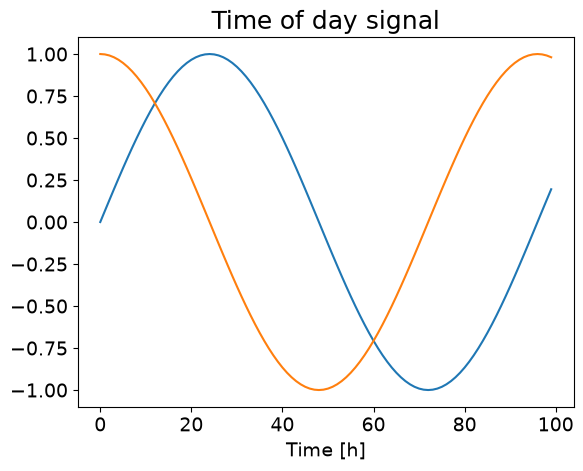

In [24]:
plt.plot(np.array(X_scaled_df['Day sin'])[:100])
plt.plot(np.array(X_scaled_df['Day cos'])[:100])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

[**Anomaly Detection**](https://www.kaggle.com/code/gmtanvirahmedrahat01/smart-grid-anomaly-detection-with-transformer)

In [40]:
# Do without art wrapper
n_timesteps, n_features = X_train.shape[1], X_train.shape[2]

def create_model():
    model = keras.Sequential([
        layers.Input(shape=(n_timesteps, n_features)),
        
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.Dropout(0.5),
        
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(), # Reduces the sequence to a single vector
        
        layers.Dense(2, activation='softmax') # Output layer for binary classification
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

    # model.summary()
    return model

In [32]:
print("Check anomaly distribution in training and validation sets:")
print("Train:", np.bincount(y_train.astype(int)))
total_train = len(y_train)
class_0_percentage = np.bincount(y_train.astype(int))[0] / total_train
class_1_percentage = np.bincount(y_train.astype(int))[1] / total_train
print(f"Class 0 (Normal) percentage in training set: {class_0_percentage:.2%}")
print(f"Class 1 (Anomaly) percentage in training set: {class_1_percentage:.2%}")
print("Val:  ", np.bincount(y_val.astype(int)))

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

Check anomaly distribution in training and validation sets:
Train: [26274  3723]
Class 0 (Normal) percentage in training set: 87.59%
Class 1 (Anomaly) percentage in training set: 12.41%
Val:   [8695 1305]


In [ ]:
save_model = False
train_model = False
model_path = 'model_output/Anomaly_1D_CNN.keras'


if train_model:
    model = create_model()
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=30,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        callbacks=[keras.callbacks.EarlyStopping(patience=10,min_delta=0.0001, restore_best_weights=True)]
    )
    print("--- Training Complete ---")
    if save_model:
        # check if a model is already saved
        if os.path.exists(model_path):
            saved_model = keras.models.load_model(model_path)
            # check if newly trained model is better than existing one
            y_pred = np.argmax(saved_model.predict(X_val), axis=1)
            saved_report = classification_report(y_val, y_pred, output_dict=True)
            f1_class1_saved = saved_report['1']['f1-score']
            # f1 score of newly trained model
            y_pred_new = np.argmax(model.predict(X_val), axis=1)
            new_report = classification_report(y_val, y_pred_new, output_dict=True)
            f1_class1_new = new_report['1']['f1-score']
            if f1_class1_new > f1_class1_saved:
                model.save(model_path)
                print(f"New model saved with improved F1-score for class 1: {f1_class1_new:.4f} (previous: {f1_class1_saved:.4f})")
            else:
                print(f"Existing model retained with better F1-score for class 1: {f1_class1_saved:.4f} (new: {f1_class1_new:.4f})")
                print("Loading existing model...")
                model = keras.models.load_model(model_path)
        else:
            y_pred_new = np.argmax(model.predict(X_val), axis=1)
            new_report = classification_report(y_val, y_pred_new, output_dict=True)
            f1_class1_new = new_report['1']['f1-score']
            model.save(model_path)
            print(f"No existing model found. New model saved with F1-score for class 1: {f1_class1_new:.4f}")
else:
    print("Loading Model...")
    model = keras.models.load_model(model_path)


Loading Model...


In [47]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.88      0.62      0.73      8749
           1       0.13      0.40      0.20      1250

    accuracy                           0.59      9999
   macro avg       0.51      0.51      0.46      9999
weighted avg       0.79      0.59      0.66      9999

Confusion Matrix:
 [[5422 3327]
 [ 744  506]]


In [48]:
if train_model:
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

**Model Inversion Attack**

Model inversion attacks are a type of adversarial attack where an attacker attempts to reconstruct the input data that was used to train a machine learning model.


I want to include the explanations of the model's predictions in the context of a model inversion attack. This can help us understand which features the model is relying on most heavily when making its predictions, and how an attacker might exploit this information to reconstruct the input data.



"white" initialization: all features are set to 0. The coloring originates from the attack being used for image data in the original paper.

In [19]:
def get_inits(n_random=100, n_random_clipped=100, n_from_test=100):
    """
    param init_path: path to init data 
    n_random: number of random initialization
    n_random_clipped: number of random clipped initialization
    n_from_test: number of initialization from test set
    return: a dictionary containing inits
    """
    
    # check whether n_from_test is within range of test set length
    n0 = np.sum(y_test == 0)
    n1 = np.sum(y_test == 1)

    if n_from_test > n0 or n_from_test > n1:
        raise ValueError(
            f"n_from_test={n_from_test} is too large; "
            f"class 0 has {n0} items and class 1 has {n1} items."
        )
    x_init_white = np.zeros((1, 2, 4, 16))
    x_init_grey = np.zeros((1, 2, 4, 16)) + 0.5
    x_init_black = np.ones((1, 2, 4, 16))
    x_init_minus = np.zeros((1, 2, 4, 16)) - 1
    x_init_average = np.broadcast_to(np.mean(X_test, axis=0), (2, 4, 16))[np.newaxis, ...]

    mean_0 = np.mean(X_test[y_test == 0], axis=0)
    mean_1 = np.mean(X_test[y_test == 1], axis=0)
    x_init_average_class = np.stack([mean_0, mean_1], axis=0)[None, :, :]
    x_init_random = np.random.uniform(-1, 1, (n_random, 2, 4, 16))
    x_init_random_clipped = np.random.uniform(clip_min, clip_max, (n_random_clipped, 2, 4, 16))

    idx_0 = np.random.choice(np.where(y_test == 0)[0], size=n_from_test, replace=False)
    idx_1 = np.random.choice(np.where(y_test == 1)[0], size=n_from_test, replace=False)
    x_init_from_test = np.stack((X_test[idx_0], X_test[idx_1]), axis=1)


    return {
        "results_white": x_init_white,
        "results_grey": x_init_grey,
        "results_black": x_init_black,
        "results_minus": x_init_minus,
        "results_average": x_init_average,
        "results_average_class": x_init_average_class,
        "results_random": x_init_random,
        "results_random_clipped": x_init_random_clipped,
        "results_from_test": x_init_from_test
        }

In [20]:
def MinvAattack(x_init, y, ArtClassifier, attack):
    """
    param x_init: initial input for the attack (shape: (2, 4, 16)
    param y: target labels for the attack (shape: (2,))
    param ArtClassifier: the ART classifier object used for the attack
    param attack: the attack object
    return: a dictionary containing the inferred input from the attack, the maximum class gradient, and the minimum over all maximum class gradients
    """

    class_gradient = ArtClassifier.class_gradient(x_init, y)
    class_gradient = np.reshape(class_gradient, (2, 4*16))
    class_gradient_max = np.max(class_gradient, axis=1)
    maximum_class_gradient = (np.max(np.abs(ArtClassifier.class_gradient(x_init, y))))
    minimum_over_all_maximum = (np.min(class_gradient_max))

    x_infer = attack.infer(x_init, y)

    return {
        "x_infer": x_infer,
        "maximum_class_gradient": maximum_class_gradient,
        "minimum_over_all_maximum": minimum_over_all_maximum
    }


In [ ]:
# check similarity
# flattened data euclidean distance
# dtw not needed since X_train is in 4 sequence blocks and shuffled
def find_nearest_windows(datapoint, dataset, top_k=3):

    dataset_flat = dataset.reshape(dataset.shape[0], -1)
    datapoint_flat = datapoint.flatten()
    
    nn = NearestNeighbors(n_neighbors=top_k, metric='euclidean')
    nn.fit(dataset_flat)
    distances, indices = nn.kneighbors([datapoint_flat])
    
    return indices[0], distances[0]


In [22]:
def check_similarity(x_infer, dataset, top_k=3):
    """
    param x_infer: the inferred input from the attack (shape: (2, 4, 16))
    param dataset: the dataset to compare against (training set)
    param top_k: the number of nearest neighbors to find
    return: a dictionary containing the indices and distances of the nearest neighbors for each class
    """
    datapoint_0 = x_infer[0]
    datapoint_1 = x_infer[1]

    indices_0, distances_0 = find_nearest_windows(datapoint_0, dataset, top_k)
    indices_1, distances_1 = find_nearest_windows(datapoint_1, dataset, top_k)

    return {
        "indices_0": indices_0,
        "distances_0": distances_0,
        "indices_1": indices_1,
        "distances_1": distances_1
    }

**XAI**

SHAP

In [23]:
def get_shap_values(model, X_train, X_test, dataset_rs, background_size, n_samples):
    """
    Compute SHAP values for the given model and data.
    param model: the trained target model
    param X_train: training data (shape: (N, 4, 16))
    param X_test: test data (shape: (N, 4, 16))
    param dataset_rs: random state for dataset splitting
    param n_samples: number of test samples to explain
    return: SHAP values for the test data
    """
    explanation_path = Path.cwd() / "model_output" / f"explanations_anomalyCNN_{dataset_rs}"
    explanation_path.mkdir(parents=True, exist_ok=True)
    if len(X_test) < n_samples:
        print("n_sample bigger than length of test set, value set to max length possible")
        explanation_file = explanation_path / f"shap_values_n_{len(X_test)}.npy"
    else:
        explanation_file = explanation_path / f"shap_values_n_{n_samples}.npy"
    # Check if explanations already exist

    if explanation_file.exists():
        print(f"Pre computed test explanation for dataset_rs={dataset_rs} exist. Loading explanation...")
        shap_values = np.load(explanation_file, allow_pickle=True)
        return shap_values
    else:


        # Stratified Background sampling (for imbalanced data)
        # Check class distribution
        n_positive = np.sum(y_train == 1)
        n_negative = np.sum(y_train == 0)
        print(f"Training class distribution: 0={n_negative} ({n_negative/len(y_train)*100:.1f}%), "
            f"1={n_positive} ({n_positive/len(y_train)*100:.1f}%)")
        

        # Stratified sampling: preserve the same class ratio in background
        background, _, background_labels, _ = train_test_split(
            X_train, 
            y_train, 
            train_size=background_size,  # Total background samples
            stratify=y_train,  # Preserves class distribution
            random_state=42
        )
        
        # Create explainer with stratified background
        explainer = shap.DeepExplainer(model, background)

        
        test_samples = min(n_samples, len(X_test))
        samples_to_explain = X_test[:test_samples]

        shap_values = explainer.shap_values(samples_to_explain)
        np.save(explanation_file, shap_values)
        return shap_values



**Model Inversion Attack** with Explanations

In [28]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj

In [29]:
"""
param run_type: type of the attack (plain or with SHAP)
param init_group: type of initialization
param x_init: initialization to infer from
param y: classes
param classifier: target classifier
param attack_obj: model inversion attack
param dataset_t: training dataset
param top_k: number of closest distance to save
param init_index: number of index for differentiating multiple x_inits of same type
return item: attack results in json compatible format
"""
def run_single_init(run_type, init_group, init_index, x_init, y, classifier, attack_obj, dataset_t, top_k=3, meta=None):
    
    attack_result = MinvAattack(x_init, y, classifier, attack_obj)
    sim = check_similarity(attack_result["x_infer"], dataset_t, top_k=top_k)

    item = {
        "run": run_type,
        "init_group": init_group,
        "init_index": int(init_index),
        "x_init": x_init,
        "attack": {
            "x_infer": attack_result["x_infer"],
            "maximum_class_gradient": attack_result["maximum_class_gradient"],
            "minimum_over_all_maximum": attack_result["minimum_over_all_maximum"],
            "indices_0": sim["indices_0"],
            "distances_0": sim["distances_0"],
            "indices_1": sim["indices_1"],
            "distances_1": sim["distances_1"],
        }
    }
    if meta is not None:
        item["meta"] = meta
    return item

In [30]:
"""
check whether the attack entry exists
"""
def run_item_exists(result_data, run_type, init_group, init_index, meta=None):
    return any(
        item.get("run") == run_type
        and item.get("init_group") == init_group
        and item.get("init_index") == init_index
        and (meta is None or item.get("meta") == meta)
        for item in result_data
    )

In [31]:
def atomic_save_results(result_data, results_path):
    results_path = Path(results_path)
    tmp_path = results_path.parent / (results_path.stem + ".tmp.json")
    with open(tmp_path, "w") as f:
        json.dump(make_json_safe(result_data), f, indent=2)
    os.replace(tmp_path, results_path)


In [32]:
def process_init_group(
    result_data,
    results_path,
    run_type,
    init_group,
    init_values_group,
    attack_obj,
    y,
    classifier,
    dataset_t,
    top_k=3,
    meta=None
):
    for i in tqdm(range(init_values_group.shape[0])):
        # check whether the entry exist in json
        if run_item_exists(result_data, run_type, init_group, i, meta):
            continue
        # run the attack and calculate the similarity distance
        x_init = init_values_group[i]
        results = run_single_init(run_type, init_group, i, x_init, y, classifier, attack_obj, dataset_t, top_k=top_k, meta=meta)
        result_data.append(results)
        atomic_save_results(result_data, results_path)
        
    return result_data

In [ ]:
"""
scale-able
:param rs_list: list of random state, also used as identification of the run
:param visualize: fine granular visualization of each step. Turn off to declutter output
:param dataset_rs: random state for splitting the dataset
"""
n_expl_list = [100] # [100, 200, 500]
background_size = 1000
visualize = False
target_model_path = 'model_output/Anomaly_1D_CNN.keras'
max_iteration = 5000
results_path = Path.cwd().parent / "model_output" / "MInvA" / f"test_results_MInvA_seed_{seed}_max_i{max_iteration}.json"
tmp_path = results_path.with_suffix(".tmp")
# no of initializations to infer from
n_random=1
n_random_clipped=1
n_from_test=1

# Inits
# 2 since we have two classes (anomaly or not anomaly)
y = np.arange(2)
init_values = get_inits(n_random=n_random, n_random_clipped=n_random_clipped, n_from_test=n_from_test)
# Load trained target model
if os.path.exists(target_model_path):
    print("Loading Model...")
    model = keras.models.load_model(target_model_path)
else:
    raise FileNotFoundError(f"Trained model not found at {target_model_path}. Please train the model first and save it to this path.")

# Load Attack model
ArtClassifier = KerasClassifier(clip_values=(clip_min, clip_max), model=model, use_logits=False)
# vary max_iter: Maximum number of gradient descent iterations for the model inversion.
attack = MIFace(ArtClassifier, max_iter=max_iteration, threshold=0.99)
run_type = "plain"

group_order = [
    "results_white",
    "results_grey",
    "results_black",
    "results_minus",
    "results_average",
    "results_average_class",
    "results_random",
    "results_random_clipped",
    "results_from_test",
]

# Load existing data (if any)
if os.path.exists(results_path):
    print(f"Existing results found at {results_path}. Loading data...")
    with open(results_path, "r") as f:
        result_data = json.load(f)
else:
    print("No existing results found. Starting fresh.")
    results_path.parent.mkdir(parents=True, exist_ok=True)
    result_data = []

for group_name in group_order:
    process_init_group(
        result_data=result_data,
        results_path=results_path,
        run_type=run_type,
        init_group=group_name,
        init_values_group=init_values[group_name],
        attack_obj=attack,
        y=y,
        classifier=ArtClassifier,
        dataset_t=X_train,
        top_k=3,
    )

for current_run in tqdm(n_expl_list):
    shap_values = get_shap_values(model, X_train, X_test, dataset_rs, background_size, current_run)
    shap_class1 = shap_values[:, :, :, 1]  # Focus on class 1 explanations
    shap_flat = shap_class1.reshape(current_run, -1)
    shap_importance = np.abs(shap_flat).mean(axis=0) 
    shap_importance_3d = shap_importance.reshape(4, 16)
    # Load Attack model
    attack_SHAP = MIFace_SHAP(ArtClassifier, max_iter=500, threshold=1., shap_importance=shap_importance_3d, shap_weight=0.7, shap_init_ratio=0.3)
    run_type = "SHAP"

    group_order = [
        "results_white",
        "results_grey",
        "results_black",
        "results_minus",
        "results_average",
        "results_average_class",
        "results_random",
        "results_random_clipped",
        "results_from_test",
    ]

    # Load existing data (if any)
    if os.path.exists(results_path):
        print(f"Existing results found at {results_path}. Loading data...")
        with open(results_path, "r") as f:
            result_data = json.load(f)
    else:
        print("No existing results found. Starting fresh.")
        results_path.parent.mkdir(parents=True, exist_ok=True)
        result_data = []

    shap_meta = {
        "background_size": background_size,
        "n_explanation": current_run,
    }

    for group_name in group_order:
        process_init_group(
            result_data=result_data,
            results_path=results_path,
            run_type=run_type,
            init_group=group_name,
            init_values_group=init_values[group_name],
            attack_obj=attack_SHAP,
            y=y,
            classifier=ArtClassifier,
            dataset_t=X_train,
            top_k=3,
            meta=shap_meta,
        )


print(f"All runs completed. Final results saved to {results_path}.")




Loading Model...
No existing results found. Starting fresh.


  0%|          | 0/1 [00:00<?, ?it/s]

Model inversion:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Model inversion:   0%|          | 0/2 [00:00<?, ?it/s]

...

Model inversion:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 1/1 [02:32<00:00, 152.92s/it]


Model inversion:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [51:29<00:00, 1544.55s/it]

All runs completed. Final results saved to d:\MasterThesis\project\Peeking-inside-the-Grid\training\model_output\smart_grid_anomaly\test_results_MInvA_seed_42_max_i100.json.
